In [10]:
# Auto-reload setup
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from scipy.stats import mannwhitneyu, ks_2samp
print(sys.executable)

sys.path.append(os.path.abspath("../src"))

/usr/local/bin/python3


In [12]:
path = '../data/clean/STEP 3/interco_congestion_metrics.csv'
df_congestion = pd.read_csv(path, parse_dates=['Time'])
print(df_congestion.head())

   Unnamed: 0                Time                     Line   RAM  utilization  \
0         264 2025-01-01 11:00:00   Achene - Lonny 380.19   1531     0.763687   
1         273 2025-01-01 11:15:00   Achene - Lonny 380.19   1531     0.807965   
2         282 2025-01-01 11:30:00   Achene - Lonny 380.19   1531     0.854768   
3         291 2025-01-01 11:45:00   Achene - Lonny 380.19   1531     0.879877   
4        1544 2025-01-04 15:00:00  Ensdorf - Vigy VIGY2 S    722     4.063076   

   Spread FR-BE  Spread FR-DE  Spread FR-NL From  To  Flow_normalized  \
0           0.0         20.69        -16.90   FR  BE      1169.205036   
1           0.0         20.69        -16.90   FR  BE      1236.994602   
2           0.0         20.69        -16.90   FR  BE      1308.650486   
3           0.0         20.69        -16.90   FR  BE      1347.091976   
4           0.0        -26.77          2.93   FR  DE      2933.541221   

     stress  stressed  congestion_FR-BE  congestion_FR-DE  congestion_FR-N

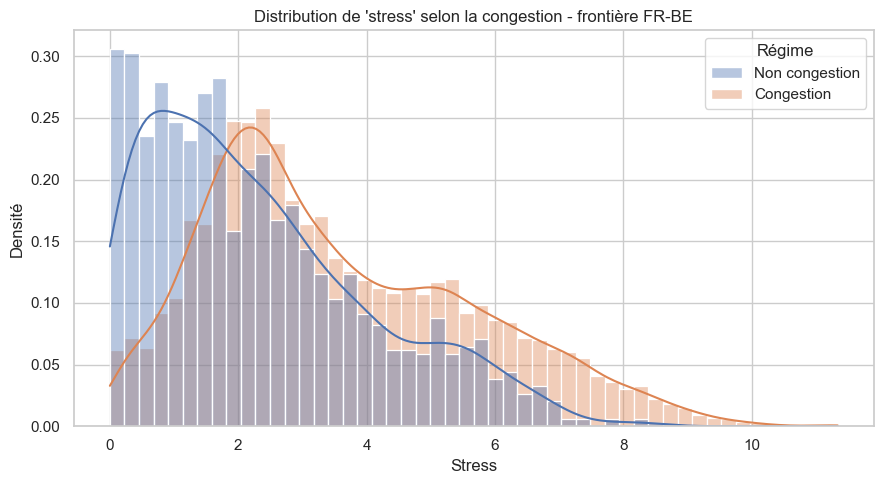

                  count      mean       std       min       25%       50%  \
Régime                                                                      
Congestion      15818.0  3.570779  2.108153  0.000825  1.961141  3.072870   
Non congestion   1500.0  2.298238  1.751552  0.000480  0.893851  1.871445   

                     75%        max  
Régime                               
Congestion      5.062531  11.341238  
Non congestion  3.308856   8.454365  


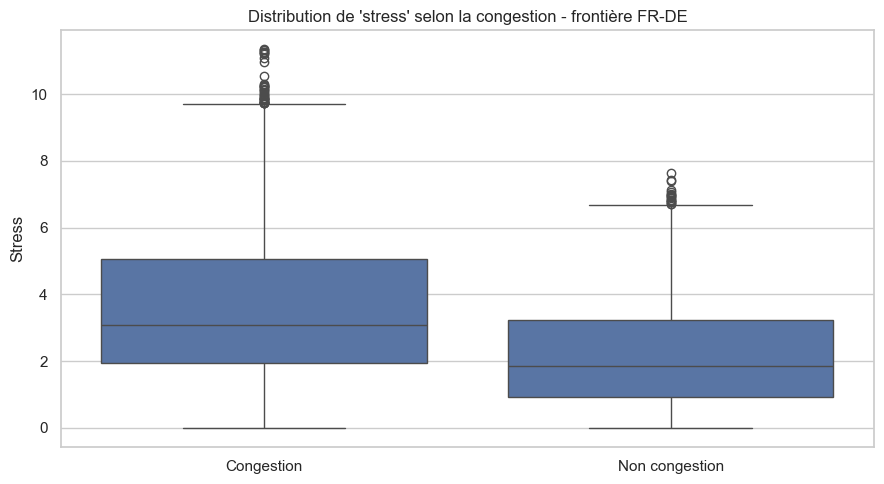

                  count      mean       std       min       25%       50%  \
Régime                                                                      
Congestion      15931.0  3.564381  2.110734  0.000825  1.955166  3.070664   
Non congestion   1387.0  2.268040  1.698333  0.000480  0.933001  1.849358   

                     75%        max  
Régime                               
Congestion      5.059888  11.341238  
Non congestion  3.232319   7.621559  


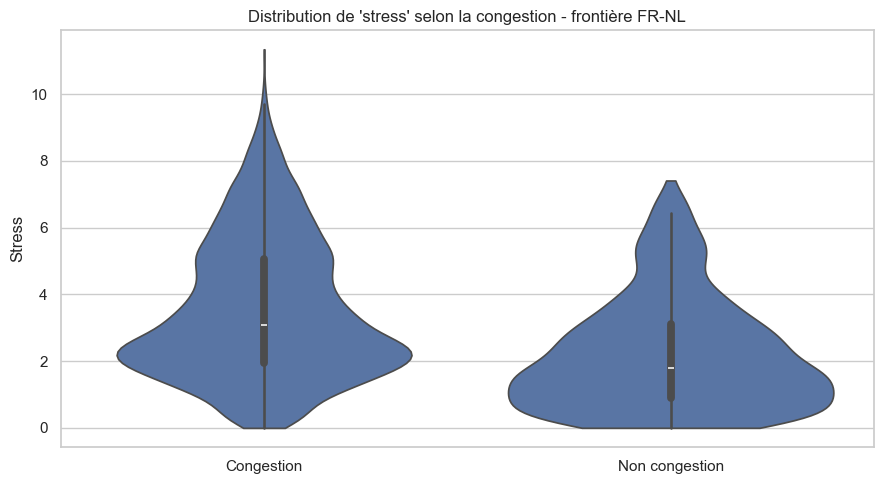

                  count      mean       std       min       25%       50%  \
Régime                                                                      
Congestion      16018.0  3.561366  2.108944  0.000480  1.954527  3.068606   
Non congestion   1300.0  2.218441  1.689243  0.002576  0.899982  1.790304   

                    75%        max  
Régime                              
Congestion      5.05351  11.341238  
Non congestion  3.12175   7.411783  


,count,mean,std,min,25%,50%,75%,max
Régime,,,,,,,,
Congestion,16018.0,3.561366,2.108944,0.000480,1.954527,3.068606,5.05351,11.341238
Non congestion,1300.0,2.218441,1.689243,0.002576,0.899982,1.790304,3.12175,7.411783


In [14]:
# =========================
# 1) Chargement du dataset
# =========================
# Adapter le chemin si besoin

# Supprime les colonnes parasites de type "Unnamed: 0" si elles existent
df_congestion = df_congestion.drop(columns=[c for c in df_congestion.columns if c.startswith("Unnamed")], errors="ignore")


# =========================================
# 2) Fonction de plot de la variable stress
# =========================================
def plot_stress_distribution(df, frontier="BE", plot_type="hist", bins=50):
    """
    Plot la distribution de 'stress' selon le régime de contrainte
    congestion ou non congestion pour une frontière donnée.

    Paramètres
    ----------
    df : pd.DataFrame
        Dataset.
    frontier : str
        Frontière étudiée : 'BE', 'DE', 'NL', etc.
        Accepte aussi 'FR-BE', 'FR-DE', ...
    plot_type : str
        Type de plot : 'hist', 'box', 'violin'
    bins : int
        Nombre de bins pour l'histogramme
    """

    # Normalisation du nom de frontière
    frontier = frontier.upper().replace(" ", "")
    if frontier.startswith("FR-"):
        frontier = frontier.split("-")[1]

    congestion_col = f"congestion_FR-{frontier}"

    if congestion_col not in df.columns:
        raise ValueError(
            f"Colonne '{congestion_col}' introuvable. "
            f"Colonnes disponibles : {[c for c in df.columns if c.startswith('congestion_')]}"
        )

    # Sous-dataframe utile
    data = df[[congestion_col, "stress"]].dropna().copy()
    data["Régime"] = data[congestion_col].map({
        True: "Congestion",
        False: "Non congestion"
    })

    # Style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(9, 5))

    # Plot selon le type choisi
    if plot_type == "hist":
        sns.histplot(
            data=data,
            x="stress",
            hue="Régime",
            bins=bins,
            kde=True,
            stat="density",
            common_norm=False,
            alpha=0.4
        )
        plt.ylabel("Densité")

    elif plot_type == "box":
        sns.boxplot(
            data=data,
            x="Régime",
            y="stress"
        )
        plt.ylabel("Stress")

    elif plot_type == "violin":
        sns.violinplot(
            data=data,
            x="Régime",
            y="stress",
            inner="box",
            cut=0
        )
        plt.ylabel("Stress")

    else:
        raise ValueError("plot_type doit être parmi : 'hist', 'box', 'violin'")

    plt.title(f"Distribution de 'stress' selon la congestion - frontière FR-{frontier}")
    plt.xlabel("Stress" if plot_type == "hist" else "")
    plt.tight_layout()
    plt.show()

    # Petit résumé statistique
    summary = data.groupby("Régime")["stress"].describe()
    print(summary)
    return summary


# =========================
# 3) Exemples d'utilisation
# =========================

# Histogramme + KDE pour la frontière BE
plot_stress_distribution(df_congestion, frontier="BE", plot_type="hist")

# Boxplot pour la frontière DE
plot_stress_distribution(df_congestion, frontier="DE", plot_type="box")

# Violin plot pour la frontière NL
plot_stress_distribution(df_congestion, frontier="NL", plot_type="violin")

In [ ]:
def frequency_df_construct(df, countries = ['DE', 'BE', 'NL'], export_col = 'export_constrained', import_col = 'import_constrained', nb_timesteps = 363):
    nb_timesteps *= 24*4 # 4 because of 15min resolution
    df = df.copy()
    df = df[['Time', 'Line', 'From', 'To', 'export_constrained', 'import_constrained']]
    new_df = df.groupby('To')[[export_col, import_col]].sum().reset_index()

    new_df['export constrained time'] = new_df[export_col] / nb_timesteps * 100
    new_df['import constrained time'] = new_df[import_col] / nb_timesteps * 100
    new_df.drop(columns=[export_col, import_col], inplace=True)

    new_df = new_df[new_df['To'].isin(countries)]
    new_df
    # print(df)
    print(new_df)
    return new_df


def plot_bar_frequency_v2(df):
    borders = df["To"].astype(str).tolist()
    export = df["export constrained time"].to_numpy()
    import_ = df["import constrained time"].to_numpy()

    x = np.arange(len(borders))
    width = 0.38

    fig, ax_left = plt.subplots(figsize=(8, 4.5))
    ax_right = ax_left.twinx()

    # Bars (side-by-side)
    bars_import = ax_right.bar(
        x + width / 2,
        import_,
        width=width,
        color="tab:green",
        label="Import",
        alpha=0.6
    )

    bars_export = ax_left.bar(
        x - width / 2,
        export,
        width=width,
        color="tab:orange",
        label="Export",
        alpha=0.5
    )

    # X axis
    ax_left.set_xticks(x)
    ax_left.set_xticklabels(borders, rotation=0)

    # Titles and labels
    ax_left.set_title("Frequency of cross-border congestion affecting France")
    ax_left.set_xlabel("Border")
    ax_left.set_ylabel("Export congestion frequency (% of time)")
    ax_right.set_ylabel("Import congestion frequency (% of time)")

    # Y limits (important)
    ax_left.set_ylim(0, export.max() * 1.15)
    ax_right.set_ylim(0, import_.max() * 1.15)

    # Legend (no Patch)
    ax_left.legend(
        handles=[bars_export, bars_import],
        labels=["Export", "Import"],
        loc="upper right"
    )

    plt.tight_layout()
    fig.savefig(f'../figures/frequency_congestion_crossborder.png'.replace(".png", ".pdf"), bbox_inches="tight")
    plt.show()
    plt.close()

plot_bar_frequency_v2(frequency_df_construct(df_spread))